In [18]:
import os
import cv2
import matplotlib.pyplot as plt

In [19]:
dataset_path = "msvd_splitted"
folders = ["train/videos", "val/videos", "test/videos"]

In [20]:
video_lengths = []
temp=0
count=0

for folder in folders:
    folder_path = os.path.join(dataset_path, folder)
    for video_file in os.listdir(folder_path):
        if video_file.endswith(('.avi', '.mp4', '.mov')):
            video_path = os.path.join(folder_path, video_file)
            cap = cv2.VideoCapture(video_path)
            
            if not cap.isOpened():
                continue
            
            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
            
            if fps > 0:
                duration = frame_count / fps
                temp=temp+duration
                count+=1
                video_lengths.append(duration)
            cap.release()

avglength=temp/count   

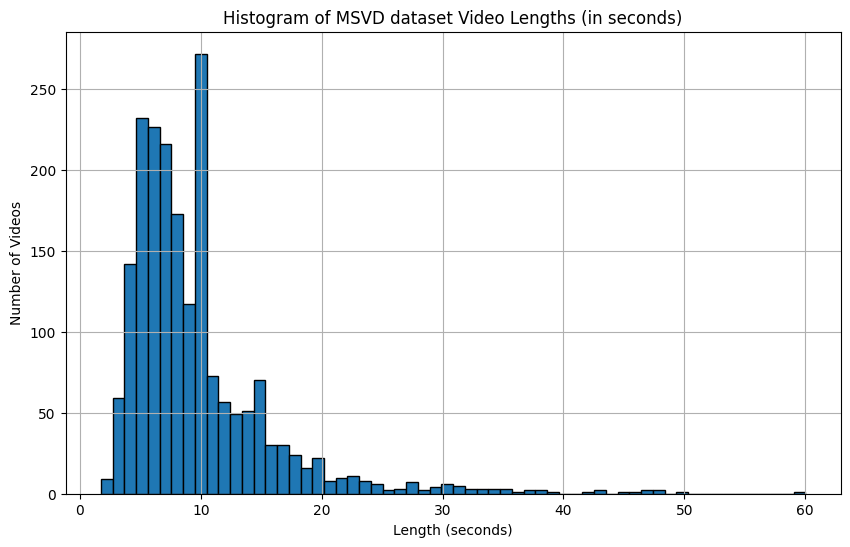

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(video_lengths, bins=60, edgecolor='black')
plt.title("Histogram of MSVD dataset Video Lengths (in seconds)")
plt.xlabel("Length (seconds)")
plt.ylabel("Number of Videos")
plt.grid(True)
plt.show()


In [22]:
print(f"Number of videos: {count}")
print(f"Total duration: {temp}")
print(f"Videos average length(in seconds): {avglength}")

Number of videos: 1970
Total duration: 19004.47962442212
Videos average length(in seconds): 9.646943971787879
